|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>More on data<h1>|
|<h2>Lecture:</h2>|<h1><b>Data oversampling in MNIST<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# A function that returns a dataset with a specified size

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labelsFull = mnist.targets.numpy()
dataFull = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labelsFull.shape)
print(dataFull.shape)

(60000,)
(60000, 784)


In [3]:
# now for the function
def makeTheDataset(dataFull, labelsFull, N, doubleTheData=False):

  # extract labels (number IDs) and remove from data
  labels = labelsFull[:N]
  data   = dataFull[:N]
  
  test_labels = labelsFull[N:]
  test_data  = dataFull[N:]
  
  # normalize the data to a range of [0 1]
  dataNorm = data / np.max(data)
  test_data = test_data / np.max(test_data)

  # make an exact copy of ALL the data
  # if doubleTheData:
  #   dataNorm = np.concatenate((dataNorm,dataNorm),axis=0)
  #   labels   = np.concatenate((labels,labels),axis=0)


  # convert to tensor
  dataT   = torch.tensor( dataNorm ).float()
  labelsT = torch.tensor( labels ).long()
  
  test_data  = torch.tensor( test_data ).float()
  test_labels = torch.tensor( test_labels ).long()

  # use scikitlearn to split the data
  train_data, dev_data, train_labels, dev_labels = train_test_split(dataT, labelsT, train_size=.9)

  # make an exact copy of the TRAIN data
  if doubleTheData:
    train_data   = torch.cat((train_data,train_data),axis=0)
    train_labels = torch.cat((train_labels,train_labels),axis=0)

  # convert into PyTorch Datasets
  train_data = TensorDataset(train_data,train_labels)
  dev_data = TensorDataset(dev_data,dev_labels)
  test_data  = TensorDataset(test_data,test_labels)

  # translate into dataloader objects
  batchsize    = 20
  train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
  dev_loader = DataLoader(dev_data,batch_size=dev_data.tensors[0].shape[0])
  test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

  return train_loader, dev_loader, test_loader

In [4]:
# Check the sizes
r,d,t = makeTheDataset(dataFull, labelsFull, 200, False)
print(r.dataset.tensors[0].shape)
print(d.dataset.tensors[0].shape)
print(t.dataset.tensors[0].shape)

r,d,t = makeTheDataset(dataFull, labelsFull, 200, True)
print(r.dataset.tensors[0].shape)
print(d.dataset.tensors[0].shape)
print(t.dataset.tensors[0].shape)

torch.Size([180, 784])
torch.Size([20, 784])
torch.Size([59800, 784])
torch.Size([360, 784])
torch.Size([20, 784])
torch.Size([59800, 784])


# Create the DL model

In [5]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

# Create a function that trains the model

In [6]:
# a function that trains the model

def function2trainTheModel(train_loader, dev_loader, numepochs=50):

  # create a new model
  net,lossfun,optimizer = createTheMNISTNet()

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  devAcc    = []

  # loop over epochs
  for epochi in range(numepochs):
    
    net.train()  # set the model to training mode

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # dev accuracy
    X,y = next(iter(dev_loader)) # extract X,y from test dataloader
    net.eval()  # set the model to evaluation mode
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      # compare the following really long line of code to the training accuracy lines
      devAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,devAcc,losses,net

# Run the model once to confirm that it works

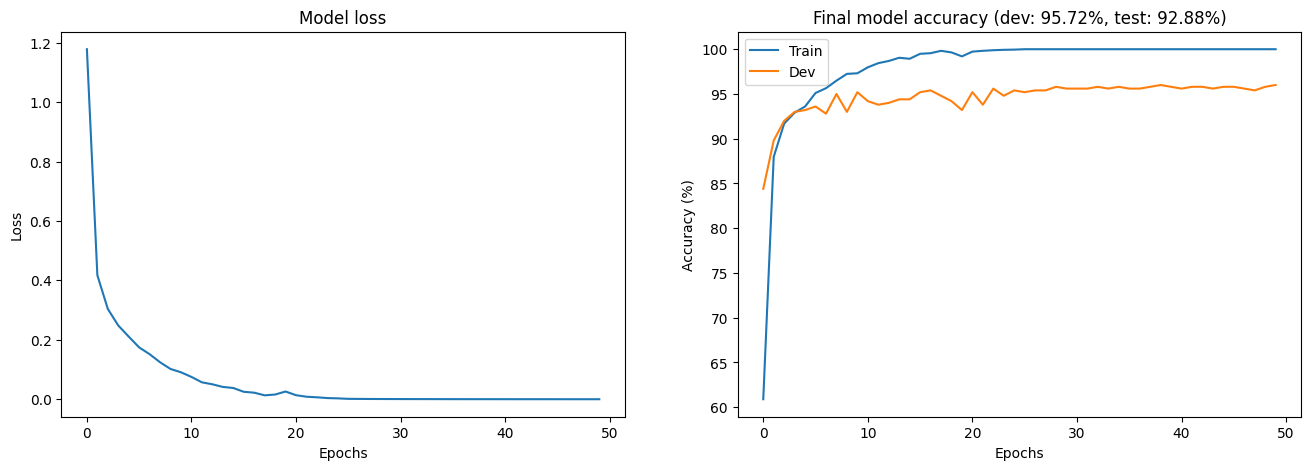

In [7]:
# generate a dataset
train_loader,dev_loader,test_loader = makeTheDataset(dataFull, labelsFull, 5000)

# test it
trainAcc,devAcc,losses,net = function2trainTheModel(train_loader, dev_loader)  # , numepochs=3)

X,y = next(iter(test_loader)) # extract X,y from test dataloader
net.eval()  # set the model to evaluation mode
testAcc = 0
with torch.no_grad(): # deactivates autograd
    yHat = net(X)
    testAcc = 100*torch.mean((torch.argmax(yHat,axis=1)==y).float())

# plot the results
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,label='Train')
ax[1].plot(devAcc,label='Dev')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
num_acc_avg = 10
ax[1].set_title(f'Final model accuracy (dev: {np.mean(devAcc[-num_acc_avg:]):.2f}%, test: {testAcc:.2f}%)')
ax[1].legend()

plt.show()

# Run an experiment showing better performance with increased N



In [8]:
# takes ~3 mins

# list of data sample sizes
samplesizes = np.arange(500,4001,500)

# initialize results matrix
resultsSingle = np.zeros((len(samplesizes),4))
resultsDouble = np.zeros((len(samplesizes),4))

def compute_testAcc(test_loader):
  X,y = next(iter(test_loader)) # extract X,y from test dataloader
  net.eval()  # set the model to evaluation mode
  testAcc = 0
  with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      testAcc = 100*torch.mean((torch.argmax(yHat,axis=1)==y).float())
  return testAcc


numepochs = 50
for idx,ssize in enumerate(samplesizes):

  ### without doubling the data!

  # generate a dataset and train the model
  train_loader,dev_loader,test_loader = makeTheDataset(dataFull, labelsFull, ssize, False)
  trainAcc,devAcc,losses,net = function2trainTheModel(train_loader, dev_loader, numepochs)
  testAcc = compute_testAcc(test_loader)

  # grab the results
  resultsSingle[idx,0] = np.mean(trainAcc[-5:])
  resultsSingle[idx,1] = np.mean(devAcc[-5:])
  resultsSingle[idx,2] = testAcc
  resultsSingle[idx,3] = torch.mean(losses[-5:]).item()

  ### with doubling the data!

  # generate a dataset and train the model
  train_loader,dev_loader,test_loader = makeTheDataset(dataFull, labelsFull, ssize,True)
  trainAcc,devAcc,losses,net = function2trainTheModel(train_loader, dev_loader, numepochs)

  # grab the results
  resultsDouble[idx,0] = np.mean(trainAcc[-5:])
  resultsDouble[idx,1] = np.mean(devAcc[-5:])
  resultsDouble[idx,2] = testAcc
  resultsDouble[idx,3] = torch.mean(losses[-5:]).item()


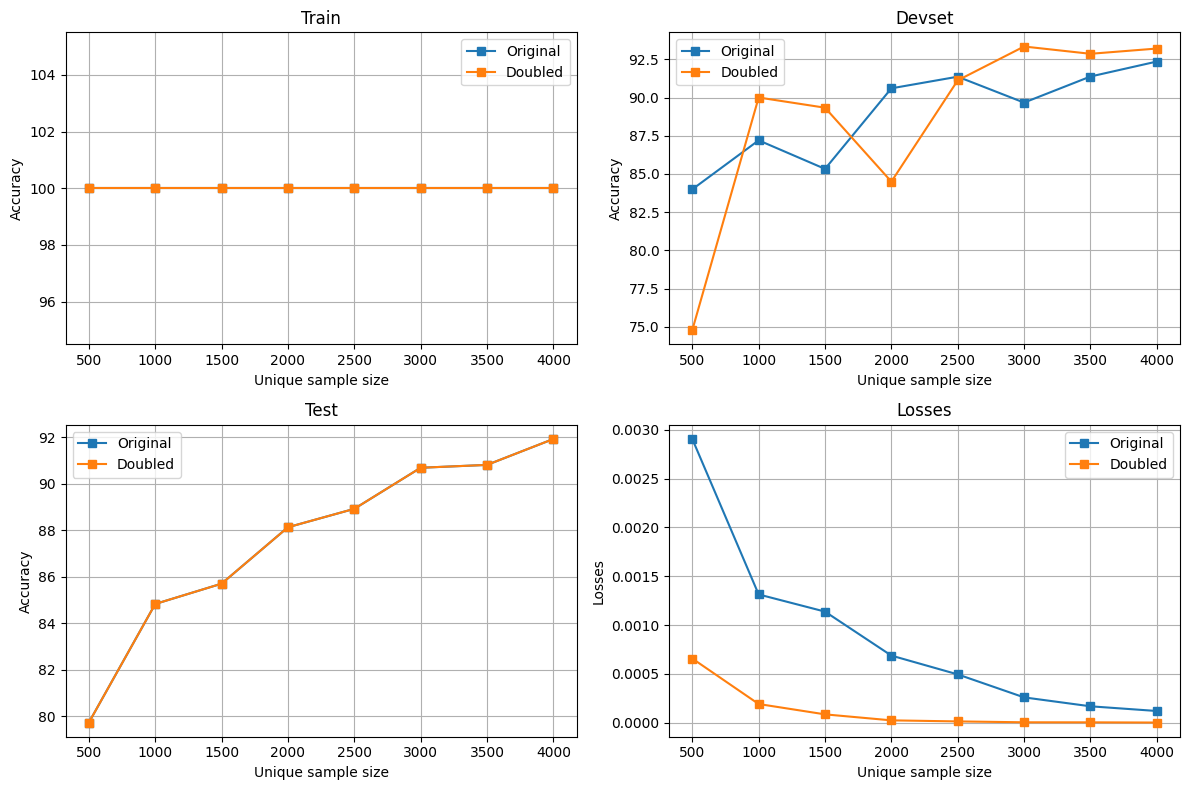

In [9]:
# Let's see what the results look like!

fig,ax = plt.subplots(2,2,figsize=(12,8))

# axis and title labels
titles    = ['Train','Devset','Test','Losses']
yaxlabels = ['Accuracy','Accuracy','Accuracy','Losses']

# common features
for i in range(4):

  # plot the lines
  ax[i//2, i%2].plot(samplesizes,resultsSingle[:,i],'s-',label='Original')
  ax[i//2, i%2].plot(samplesizes,resultsDouble[:,i],'s-',label='Doubled')

  # make it look nicer
  ax[i//2, i%2].set_ylabel(yaxlabels[i])
  ax[i//2, i%2].set_title(titles[i])
  ax[i//2, i%2].legend()
  ax[i//2, i%2].set_xlabel('Unique sample size')
  ax[i//2, i%2].grid('on')


plt.tight_layout()
plt.show()

# Additional explorations

In [10]:
# 1) Notice that we're using the "test_dataset" multiple times, which really means that it's the devset,
#    aka hold-out set, and not a true TEST set. A real test set gets evaluated only once. Modify the code
#    to create a test set, using images in dataFull that are not in dataNorm. Note that you don't need
#    to re-run the entire experiment; you only need to train two models (and save their 'net' outputs), so that
#    you can run the test data through (make sure to normalize the test data!). Then you can evaluate the test
#    performance relative to train and devset from those two models.
#
# 2) We've previously discovered that Adam can outperform SGD on the MNIST dataset. I used SGD here on purpose --
#    to make performance worse (!) so we could test for effects of oversampling. Re-run the experiment using
#    Adam to see whether you still get the same effects.
# Answer: Adam is ofcourse prone to same effects.
#